# T2 - Pipeline para classificação de poses de yoga com MediaPipe Landmarks + SVM

## Objetivo

Desenvolver uma prova de conceito para **classificar poses de yoga a partir de imagens**, utilizando **landmarks corporais** extraídos por uma rede neural pré-treinada e um classificador SVM. O pipeline é uma continuação do T1 realizado no notebook pipelineT1.ipynb.

## Setup

Instale primeiro as dependências com o `requirements.txt` que acompanha este notebook.

In [23]:
from pathlib import Path
import random

import cv2
import joblib
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm import tqdm

if not hasattr(mp, "solutions"):
    raise RuntimeError(
        "A versão instalada do MediaPipe não possui mp.solutions.pose. "
        "Use o ambiente correto e instale: pip install -r requirements-mediapipe.txt"
    )

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATASET_DIR = Path("dataset")
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
SVM_MODEL_PATH = MODEL_DIR / "t2_landmarks_svm.joblib"
METADATA_PATH = MODEL_DIR / "t2_landmarks_metadata.joblib"

assert DATASET_DIR.exists(), f"Dataset não encontrado: {DATASET_DIR.resolve()}"

print("Dataset:", DATASET_DIR.resolve())
print("MediaPipe:", getattr(mp, "__version__", "sem versão"))

Dataset: /Users/barbaradapper/Library/Mobile Documents/com~apple~CloudDocs/Desktop/2026/Visão Computacional/T1VisaoComputacional/dataset
MediaPipe: 0.10.21


## 1. Leitura do dataset

As imagens estão organizadas por pastas, em que cada pasta representa uma classe. Pastas vazias são ignoradas.

In [24]:
def load_image_table(dataset_dir, extensions):
    samples = []

    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        image_paths = sorted(
            path for path in class_dir.rglob("*")
            if path.is_file() and path.suffix.lower() in extensions
        )

        for image_path in image_paths:
            samples.append({
                "path": str(image_path),
                "label": class_dir.name,
            })

    image_df = pd.DataFrame(samples)
    assert len(image_df) > 0, "Nenhuma imagem válida encontrada."
    return image_df


image_df = load_image_table(DATASET_DIR, IMG_EXTENSIONS)
class_names = sorted(image_df["label"].unique())
class_to_id = {class_name: index for index, class_name in enumerate(class_names)}
id_to_class = {index: class_name for class_name, index in class_to_id.items()}

image_df["label_id"] = image_df["label"].map(class_to_id).astype("int32")

print("Total de imagens:", len(image_df))
print("Total de classes:", len(class_names))
display(image_df.head())

Total de imagens: 2756
Total de classes: 47


,path,label,label_id
0,dataset/afundo_alto/File1.jpeg,afundo_alto,0
1,dataset/afundo_alto/File10.jpeg,afundo_alto,0
2,dataset/afundo_alto/File11.png,afundo_alto,0
3,dataset/afundo_alto/File12.jpeg,afundo_alto,0
4,dataset/afundo_alto/File13.png,afundo_alto,0


,label,image_count
0,postura_do_camelo,96
1,meia_torcao_espinhal,96
2,postura_da_vaca,94
3,postura_da_aguia,85
4,postura_do_grou,84
5,postura_do_angulo_ligado,81
6,postura_da_cadeira,81
7,postura_da_prancha_lateral,80
8,postura_da_crianca,79
9,postura_do_lotus,77


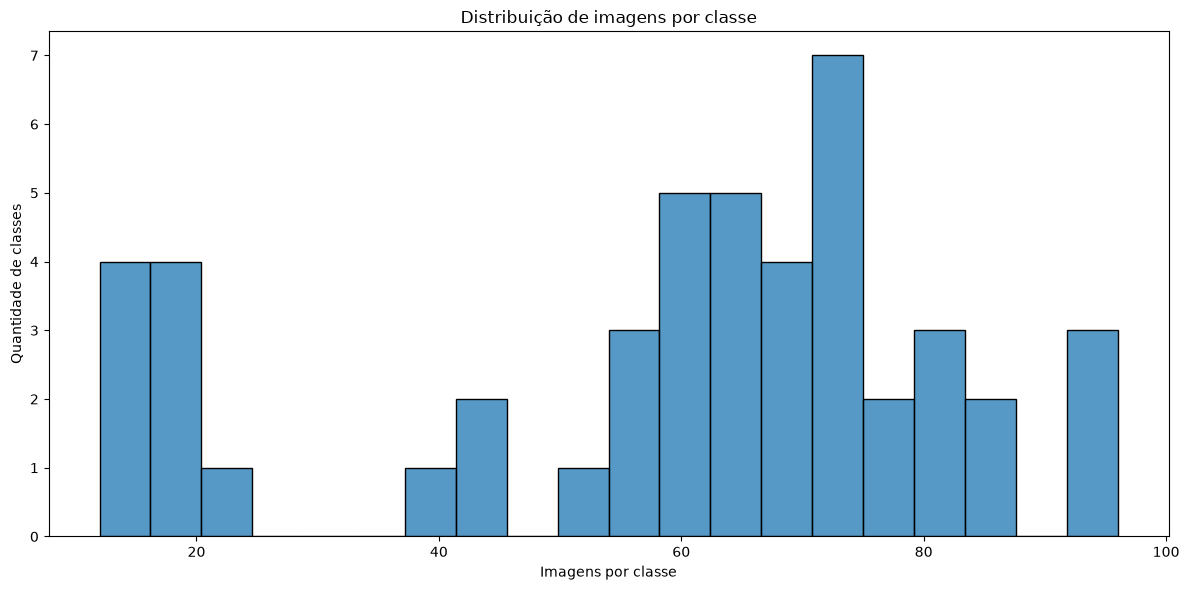

In [25]:
class_summary = (
    image_df.groupby("label")
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

display(class_summary)

plt.figure(figsize=(12, 6))
sns.histplot(class_summary["image_count"], bins=20)
plt.title("Distribuição de imagens por classe")
plt.xlabel("Imagens por classe")
plt.ylabel("Quantidade de classes")
plt.tight_layout()
plt.show()

## 2. Separação em treino, validação e teste

Usamos validação para escolher o melhor valor de `C` do SVM e teste para a avaliação final.

In [26]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=VALIDATION_SIZE + TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=image_df["label_id"],
)

test_size_adjusted = TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=test_size_adjusted,
    random_state=RANDOM_STATE,
    stratify=temp_df["label_id"],
)

print("Treino:", train_df.shape)
print("Validação:", validation_df.shape)
print("Teste:", test_df.shape)

split_summary = pd.DataFrame({
    "split": ["treino", "validacao", "teste"],
    "images": [len(train_df), len(validation_df), len(test_df)],
    "percentage": [len(train_df) / len(image_df), len(validation_df) / len(image_df), len(test_df) / len(image_df)],
})

split_summary

Treino: (1929, 3)
Validação: (413, 3)
Teste: (414, 3)


,split,images,percentage
0,treino,1929,0.699927
1,validacao,413,0.149855
2,teste,414,0.150218


## 3. Extração dos landmarks

O MediaPipe Pose retorna 33 pontos corporais. Cada ponto possui `x`, `y`, `z` e `visibility`.

Antes de treinar o SVM, normalizamos os pontos:

- centralizamos a pose no quadril;
- dividimos pelo tamanho do torso/ombros/quadril;
- reduzimos o efeito de escala e posição da pessoa na imagem.

In [27]:
POSE_LANDMARKS = 33
LANDMARK_DIMS = 4
LANDMARK_FEATURES = POSE_LANDMARKS * LANDMARK_DIMS

LEFT_SHOULDER = 11
RIGHT_SHOULDER = 12
LEFT_HIP = 23
RIGHT_HIP = 24


def normalize_landmarks(landmarks):
    points = landmarks.astype("float32").copy()

    hip_center = (points[LEFT_HIP, :2] + points[RIGHT_HIP, :2]) / 2.0
    shoulder_center = (points[LEFT_SHOULDER, :2] + points[RIGHT_SHOULDER, :2]) / 2.0

    shoulder_width = np.linalg.norm(points[LEFT_SHOULDER, :2] - points[RIGHT_SHOULDER, :2])
    hip_width = np.linalg.norm(points[LEFT_HIP, :2] - points[RIGHT_HIP, :2])
    torso_size = np.linalg.norm(shoulder_center - hip_center)
    scale = max(shoulder_width, hip_width, torso_size, 1e-6)

    points[:, 0] = (points[:, 0] - hip_center[0]) / scale
    points[:, 1] = (points[:, 1] - hip_center[1]) / scale
    points[:, 2] = points[:, 2] / scale

    return points.reshape(-1).astype("float32")


def extract_landmarks_from_image(image_path, pose):
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        return None

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    result = pose.process(image_rgb)

    if not result.pose_landmarks:
        return None

    landmarks = np.array(
        [[point.x, point.y, point.z, point.visibility] for point in result.pose_landmarks.landmark],
        dtype="float32",
    )

    if landmarks.shape != (POSE_LANDMARKS, LANDMARK_DIMS):
        return None

    return normalize_landmarks(landmarks)

In [28]:
def extract_landmarks_dataset(split_df, split_name):
    features = []
    labels = []
    valid_rows = []
    failed_paths = []

    mp_pose = mp.solutions.pose

    with mp_pose.Pose(
        static_image_mode=True,
        model_complexity=2,
        enable_segmentation=False,
        min_detection_confidence=0.30,
    ) as pose:
        for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Landmarks {split_name}"):
            landmark_vector = extract_landmarks_from_image(row["path"], pose)

            if landmark_vector is None:
                failed_paths.append(row["path"])
                continue

            features.append(landmark_vector)
            labels.append(int(row["label_id"]))
            valid_rows.append(row)

    features = np.vstack(features).astype("float32")
    labels = np.array(labels, dtype="int32")
    valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)

    print(f"{split_name}: {len(valid_df)} imagens com pose detectada / {len(split_df)}")
    print(f"{split_name}: {len(failed_paths)} imagens sem pose detectada")

    return features, labels, valid_df, failed_paths


X_train, y_train, train_valid_df, train_failed_paths = extract_landmarks_dataset(train_df, "treino")
X_val, y_val, validation_valid_df, validation_failed_paths = extract_landmarks_dataset(validation_df, "validação")
X_test, y_test, test_valid_df, test_failed_paths = extract_landmarks_dataset(test_df, "teste")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

I0000 00:00:1781477377.682714 1135121 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
Landmarks treino:   0%|          | 0/1929 [00:00<?, ?it/s]W0000 00:00:1781477377.727557 1185578 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781477377.741098 1185578 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Landmarks treino: 100%|██████████| 1929/1929 [01:54<00:00, 16.81it/s]
I0000 00:00:1781477492.432445 1135121 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4


treino: 1845 imagens com pose detectada / 1929
treino: 84 imagens sem pose detectada


Landmarks validação:   0%|          | 0/413 [00:00<?, ?it/s]W0000 00:00:1781477492.476131 1187622 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781477492.508609 1187626 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Landmarks validação: 100%|██████████| 413/413 [00:24<00:00, 16.55it/s]
I0000 00:00:1781477517.405274 1135121 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4


validação: 396 imagens com pose detectada / 413
validação: 17 imagens sem pose detectada


Landmarks teste:   0%|          | 0/414 [00:00<?, ?it/s]W0000 00:00:1781477517.448477 1188082 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781477517.461938 1188082 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Landmarks teste: 100%|██████████| 414/414 [00:25<00:00, 16.32it/s]

teste: 396 imagens com pose detectada / 414
teste: 18 imagens sem pose detectada
X_train: (1845, 132)
X_val: (396, 132)
X_test: (396, 132)


In [29]:
detection_summary = pd.DataFrame([
    {"split": "treino", "detected_images": len(train_valid_df), "total_images": len(train_df)},
    {"split": "validacao", "detected_images": len(validation_valid_df), "total_images": len(validation_df)},
    {"split": "teste", "detected_images": len(test_valid_df), "total_images": len(test_df)},
])

detection_summary["detection_rate"] = detection_summary["detected_images"] / detection_summary["total_images"]
display(detection_summary)

,split,detected_images,total_images,detection_rate
0,treino,1845,1929,0.956454
1,validacao,396,413,0.958838
2,teste,396,414,0.956522


## 4. Treinamento do SVM

Treinamos um SVM com kernel RBF. O `StandardScaler` padroniza os landmarks antes da classificação.

O melhor valor de `C` é escolhido no conjunto de validação.

In [30]:
validation_results = []
best_model = None
best_accuracy = -1
best_C = None

for C in [0.1, 1, 3, 10, 30, 100]:
    svm_model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C, gamma="scale", class_weight="balanced", probability=True)),
    ])

    svm_model.fit(X_train, y_train)
    y_val_pred = svm_model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)

    validation_results.append({"C": C, "validation_accuracy": val_accuracy})

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_C = C
        best_model = svm_model


df_validation = pd.DataFrame(validation_results)
display(df_validation)

print("Melhor C:", best_C)
print(f"Melhor acurácia na validação: {best_accuracy:.4f}")

/Users/barbaradapper/Library/Mobile Documents/com~apple~CloudDocs/Desktop/2026/Visão Computacional/T1VisaoComputacional/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/barbaradapper/Library/Mobile Documents/com~apple~CloudDocs/Desktop/2026/Visão Computacional/T1VisaoComputacional/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/barbaradapper/Library/Mobile Documents/com~apple~CloudDocs/Desktop/2026/Visão Computacional/T1VisaoComputacional/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter

,C,validation_accuracy
0,0.1,0.383838
1,1.0,0.775253
2,3.0,0.830808
3,10.0,0.830808
4,30.0,0.825758
5,100.0,0.808081


Melhor C: 3
Melhor acurácia na validação: 0.8308


## 5. Avaliação final

O teste é usado apenas no final, depois da escolha do melhor `C`.

In [31]:
y_pred = best_model.predict(X_test)
y_confidence = best_model.predict_proba(X_test).max(axis=1)

accuracy_landmarks_svm = accuracy_score(y_test, y_pred)

print(f"Acurácia no teste com MediaPipe landmarks + SVM: {accuracy_landmarks_svm:.4f}")
print(f"Acurácia percentual: {accuracy_landmarks_svm * 100:.2f}%")
print(classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0,
))

Acurácia no teste com MediaPipe landmarks + SVM: 0.8561
Acurácia percentual: 85.61%
                                        precision    recall  f1-score   support

                           afundo_alto       0.00      0.00      0.00         1
           alongamento_lateral_intenso       0.60      0.50      0.55         6
                 angulo_aberto_sentado       1.00      1.00      1.00         2
                               cadaver       1.00      1.00      1.00         3
                              espatada       1.00      1.00      1.00         6
                          flexao_em_pe       0.75      0.82      0.78        11
               flexao_sentada_a_frente       0.88      0.88      0.88         8
                              golfinho       0.56      0.62      0.59         8
                        guerreiro_dois       1.00      1.00      1.00         9
                     guerreiro_lateral       0.50      1.00      0.67         2
                        guerreiro_t

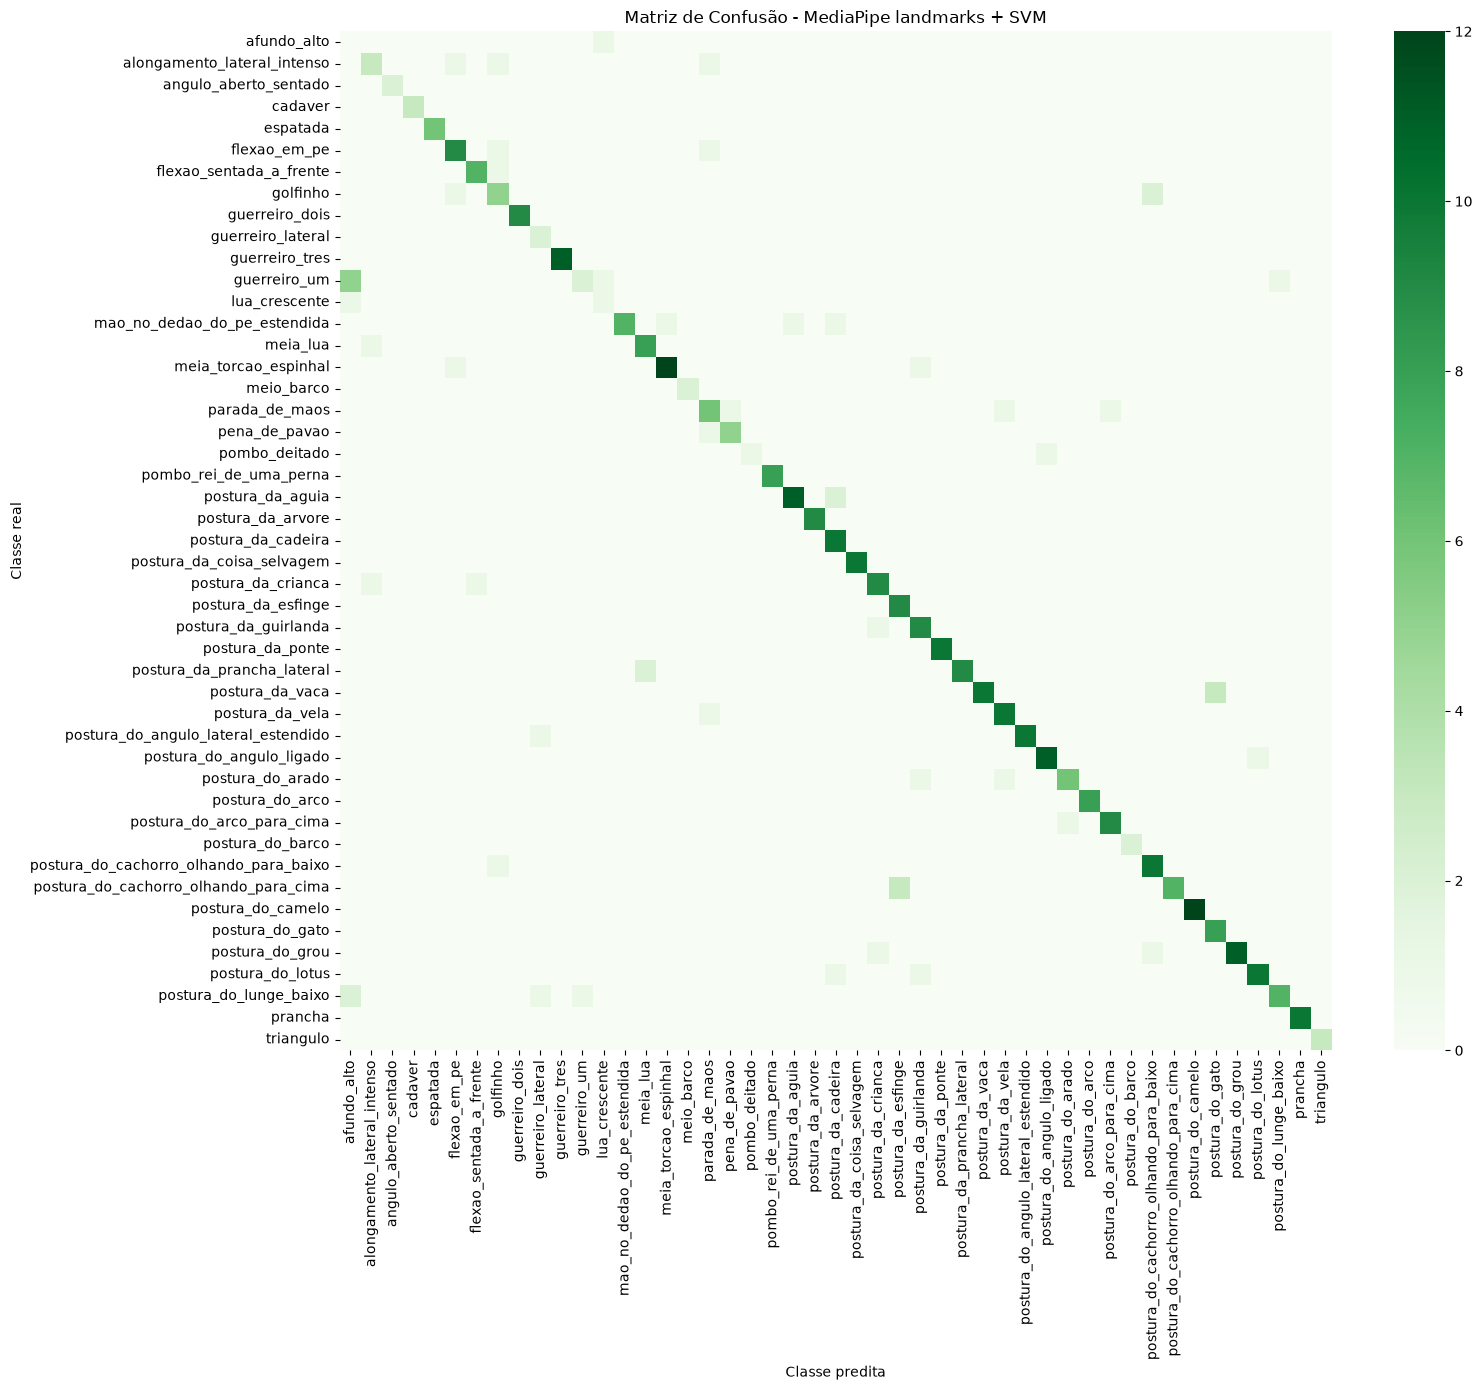

In [32]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
)
plt.title("Matriz de Confusão - MediaPipe landmarks + SVM")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Análise dos erros

Esta tabela ajuda a explicar quais poses ainda são confundidas.

In [33]:
results_df = test_valid_df.copy().reset_index(drop=True)
results_df["true_id"] = y_test
results_df["pred_id"] = y_pred
results_df["true_label"] = [id_to_class[int(label)] for label in y_test]
results_df["pred_label"] = [id_to_class[int(label)] for label in y_pred]
results_df["confidence"] = y_confidence

errors_df = results_df[results_df["true_id"] != results_df["pred_id"]]

print("Total de amostras de teste com pose detectada:", len(results_df))
print("Total de erros:", len(errors_df))
print(f"Taxa de erro: {len(errors_df) / len(results_df):.4f}")

display(results_df.head())

Total de amostras de teste com pose detectada: 396
Total de erros: 57
Taxa de erro: 0.1439


,path,label,label_id,true_id,pred_id,true_label,pred_label,confidence
0,dataset/postura_da_coisa_selvagem/File41.png,postura_da_coisa_selvagem,24,24,24,postura_da_coisa_selvagem,postura_da_coisa_selvagem,0.825200
1,dataset/meia_torcao_espinhal/File27.png,meia_torcao_espinhal,15,15,15,meia_torcao_espinhal,meia_torcao_espinhal,0.438859
2,dataset/postura_do_arco/File13.png,postura_do_arco,35,35,35,postura_do_arco,postura_do_arco,0.733159
3,dataset/flexao_em_pe/File14.png,flexao_em_pe,5,5,5,flexao_em_pe,flexao_em_pe,0.596734
4,dataset/guerreiro_dois/File42.png,guerreiro_dois,8,8,8,guerreiro_dois,guerreiro_dois,0.721027


In [34]:
confused_pairs = (
    errors_df.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

display(confused_pairs)

,true_label,pred_label,count
9,guerreiro_um,afundo_alto,5
29,postura_da_vaca,postura_do_gato,3
37,postura_do_cachorro_olhando_para_cima,postura_da_esfinge,3
42,postura_do_lunge_baixo,afundo_alto,2
28,postura_da_prancha_lateral,meia_lua,2
8,golfinho,postura_do_cachorro_olhando_para_baixo,2
24,postura_da_aguia,postura_da_cadeira,2
0,afundo_alto,lua_crescente,1
33,postura_do_arado,postura_da_guirlanda,1
26,postura_da_crianca,flexao_sentada_a_frente,1


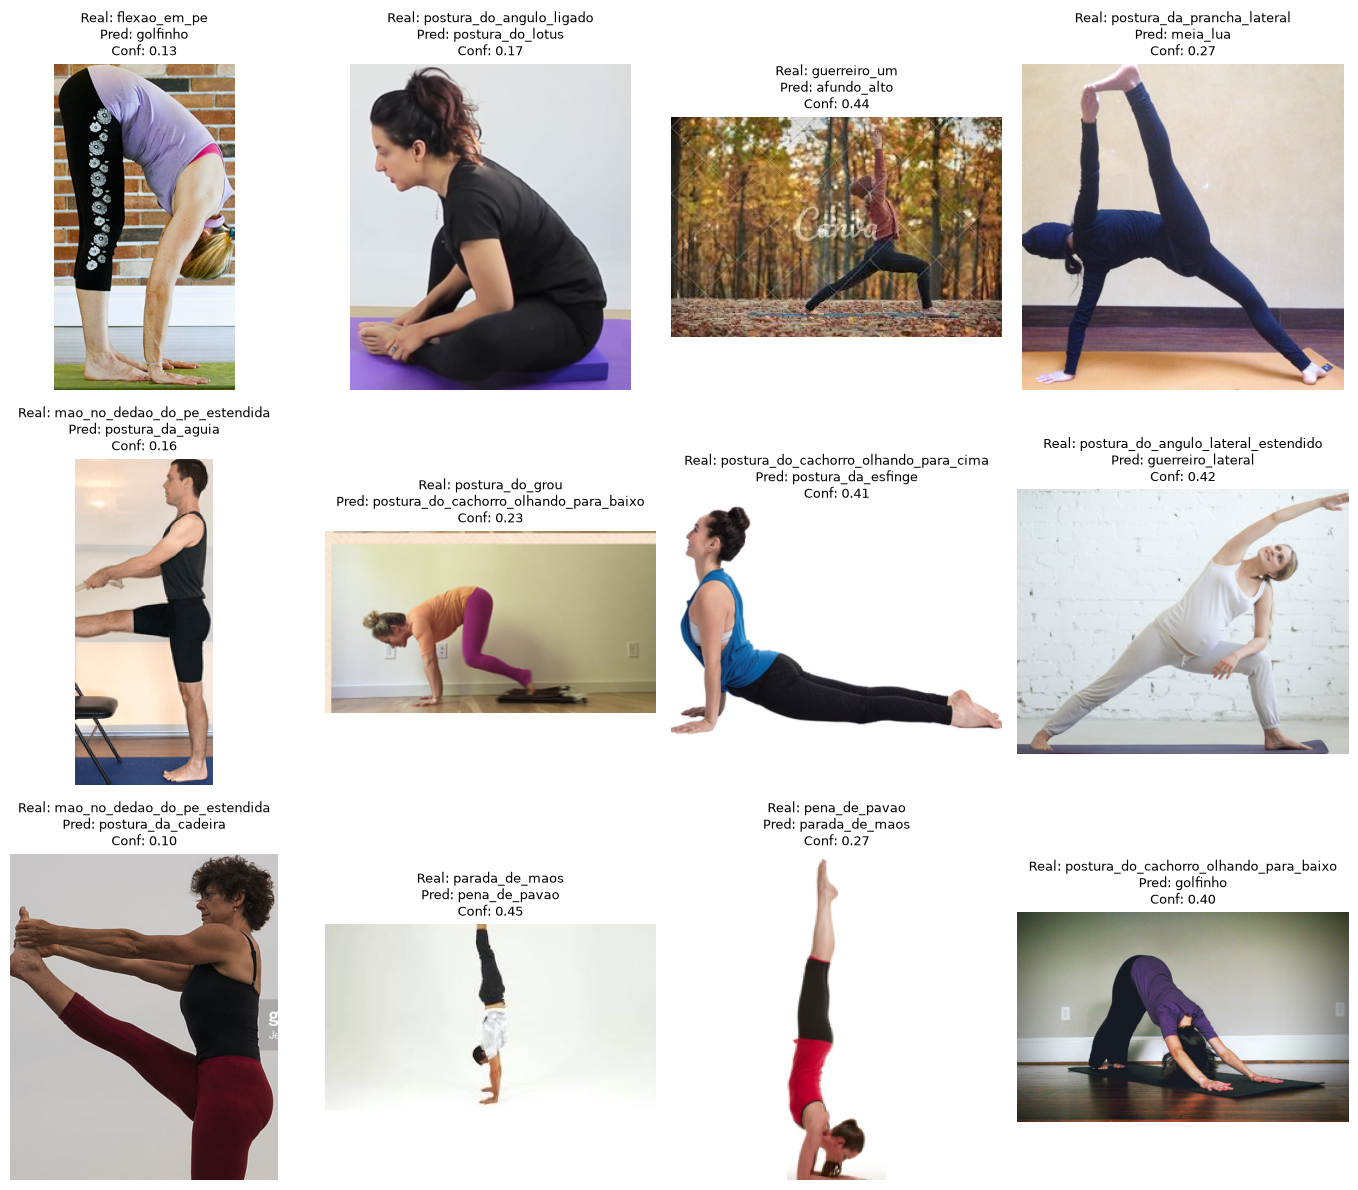

In [35]:
def show_error_examples(errors_df, n=12):
    if len(errors_df) == 0:
        print("Nenhum erro encontrado.")
        return

    samples = errors_df.sample(n=min(n, len(errors_df)), random_state=RANDOM_STATE).reset_index(drop=True)
    cols = 4
    rows = int(np.ceil(len(samples) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for i, row in samples.iterrows():
        image_bgr = cv2.imread(row["path"])
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image_rgb)
        plt.title(
            f"Real: {row['true_label']}\nPred: {row['pred_label']}\nConf: {row['confidence']:.2f}",
            fontsize=9,
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_error_examples(errors_df)

## 7. Comparação com o T1

Resultados de referência do T1:

- Pixels crus + SVM: **47,46%**
- HOG + SVM: **69,57%**

O resultado deste notebook mostra o ganho ao trocar a representação da imagem por landmarks corporais.

,experiment,accuracy,accuracy_percent
0,Pixels crus + SVM (T1),0.474600,47.460000
1,HOG + SVM (T1),0.695700,69.570000
2,MediaPipe landmarks + SVM (T2),0.856061,85.606061


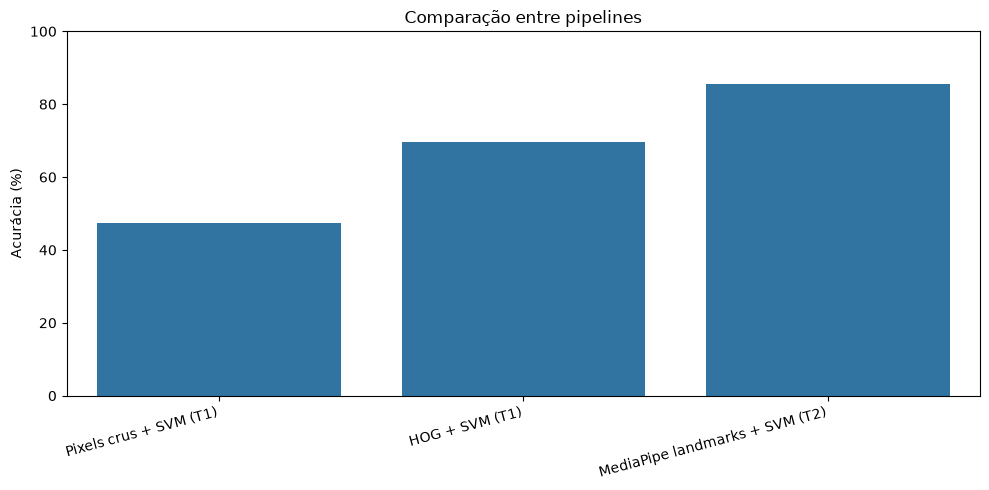

In [36]:
comparison_df = pd.DataFrame([
    {"experiment": "Pixels crus + SVM (T1)", "accuracy": 0.4746},
    {"experiment": "HOG + SVM (T1)", "accuracy": 0.6957},
    {"experiment": "MediaPipe landmarks + SVM (T2)", "accuracy": accuracy_landmarks_svm},
])

comparison_df["accuracy_percent"] = comparison_df["accuracy"] * 100
display(comparison_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="experiment", y="accuracy_percent")
plt.title("Comparação entre pipelines")
plt.ylabel("Acurácia (%)")
plt.xlabel("")
plt.ylim(0, 100)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 8. Salvando o modelo

O modelo final e os metadados das classes são salvos para permitir demo posterior.

In [37]:
joblib.dump(best_model, SVM_MODEL_PATH)
joblib.dump(
    {
        "class_names": class_names,
        "class_to_id": class_to_id,
        "id_to_class": id_to_class,
        "best_C": best_C,
        "test_accuracy": accuracy_landmarks_svm,
        "landmark_features": LANDMARK_FEATURES,
    },
    METADATA_PATH,
)

print("Modelo salvo em:", SVM_MODEL_PATH)
print("Metadados salvos em:", METADATA_PATH)

Modelo salvo em: models/t2_landmarks_svm.joblib
Metadados salvos em: models/t2_landmarks_metadata.joblib


## 9. Demo com uma imagem

A célula abaixo faz uma demostração completa do pipeline com uma imagem da classe escolhida.

I0000 00:00:1781479013.185472 1135121 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1781479013.233347 1209982 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781479013.246274 1209982 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


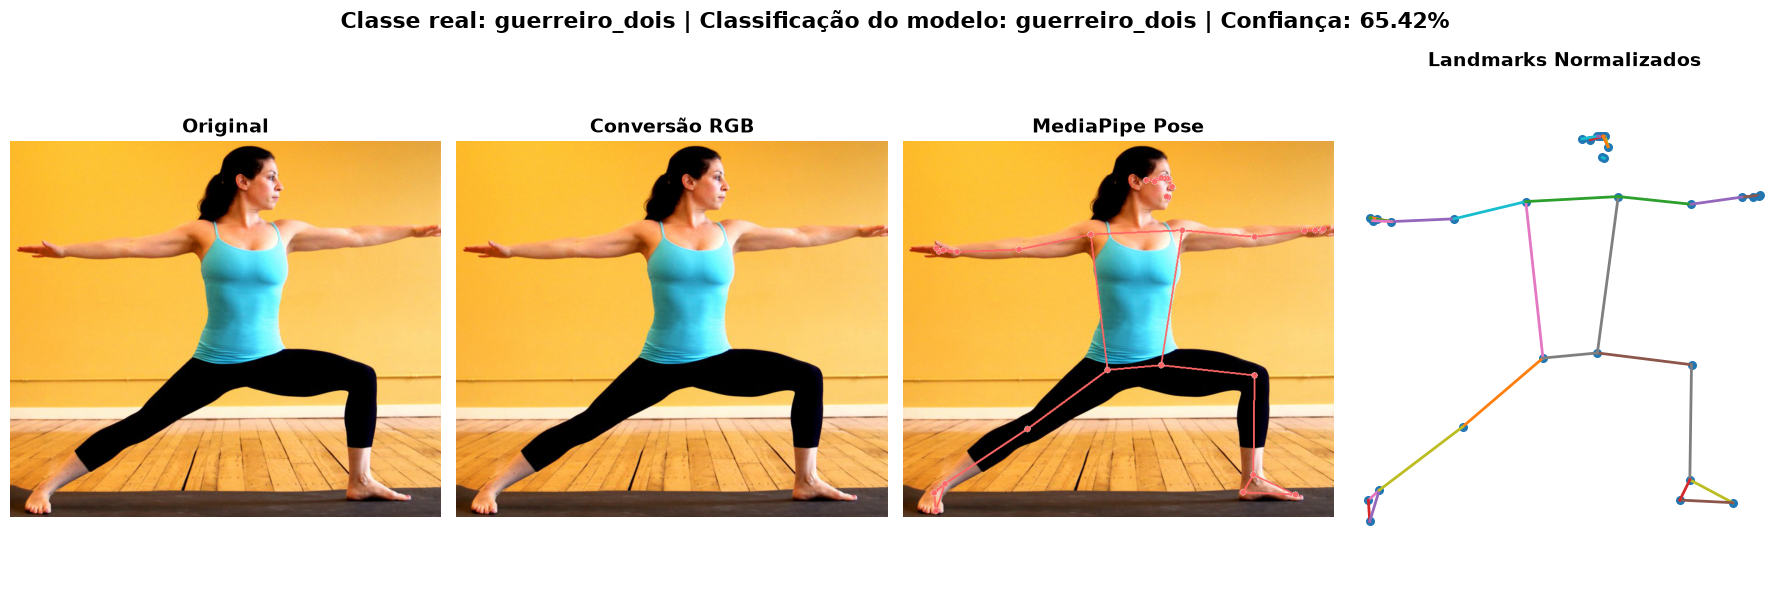

Imagem utilizada: dataset/guerreiro_dois/File7.png
Classe real: guerreiro_dois
Classe prevista: guerreiro_dois
Confiança: 65.42%


In [70]:
pose_escolhida = "guerreiro_dois"

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

amostras_pose = test_valid_df[test_valid_df["label"] == pose_escolhida]

if len(amostras_pose) == 0:
    print(f"Nenhuma imagem encontrada para a pose: {pose_escolhida}")
    print("\nClasses disponíveis:")
    print(sorted(test_valid_df["label"].unique()))

else:
    demo_sample = amostras_pose.sample(n=1, random_state=RANDOM_STATE).iloc[0]
    image_path = demo_sample["path"]
    classe_real = demo_sample["label"]

    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        print("Erro ao carregar a imagem:", image_path)

    else:
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        with mp_pose.Pose(
            static_image_mode=True,
            model_complexity=2,
            enable_segmentation=False,
            min_detection_confidence=0.30
        ) as pose:

            results = pose.process(image_rgb)

        if not results.pose_landmarks:
            print("Não foi possível detectar landmarks na imagem.")

        else:
            raw_landmarks = np.array(
                [[lm.x, lm.y, lm.z, lm.visibility] for lm in results.pose_landmarks.landmark],
                dtype="float32"
            )

            normalized_vector = normalize_landmarks(raw_landmarks)

            probabilities = best_model.predict_proba(normalized_vector.reshape(1, -1))[0]
            predicted_index = int(np.argmax(probabilities))
            predicted_class = id_to_class[predicted_index]
            confidence = probabilities[predicted_index]

            image_with_pose = image_rgb.copy()

            mp_drawing.draw_landmarks(
                image_with_pose,
                results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(255, 102, 102), thickness=2, circle_radius=3),
                mp_drawing.DrawingSpec(color=(255, 102, 102), thickness=2)
            )

            def draw_normalized_landmarks(normalized_vector):
                points = normalized_vector.reshape(33, 4)

                plt.scatter(points[:, 0], -points[:, 1], s=30)

                for start, end in mp_pose.POSE_CONNECTIONS:
                    x_values = [points[start, 0], points[end, 0]]
                    y_values = [-points[start, 1], -points[end, 1]]
                    plt.plot(x_values, y_values, linewidth=2)

                plt.axis("equal")
                plt.axis("off")

            plt.figure(figsize=(18, 6))

            plt.subplot(1, 4, 1)
            plt.imshow(image_rgb)
            plt.title("Original", fontsize=14, fontweight="bold")
            plt.axis("off")

            plt.subplot(1, 4, 2)
            plt.imshow(image_rgb)
            plt.title("Conversão RGB", fontsize=14, fontweight="bold")
            plt.axis("off")

            plt.subplot(1, 4, 3)
            plt.imshow(image_with_pose)
            plt.title("MediaPipe Pose", fontsize=14, fontweight="bold")
            plt.axis("off")

            plt.subplot(1, 4, 4)
            draw_normalized_landmarks(normalized_vector)
            plt.title("Landmarks Normalizados", fontsize=14, fontweight="bold")

            plt.suptitle(
                f"Classe real: {classe_real} | Classificação do modelo: {predicted_class} | Confiança: {confidence:.2%}",
                fontsize=16,
                fontweight="bold"
            )

            plt.tight_layout()
            plt.show()

            print("Imagem utilizada:", image_path)
            print("Classe real:", classe_real)
            print("Classe prevista:", predicted_class)
            print(f"Confiança: {confidence:.2%}")